# Faster R-CNN Training Notebook for Kaggle

This notebook is designed to train the **Faster R-CNN model** on a synthetic MNIST multi-digit dataset. By running this notebook on **Kaggle** with a GPU accelerator, training will complete significantly faster (under 3 minutes) compared to training locally on a CPU.

## Kaggle Setup Instructions
1. **Create a Kaggle account** (if you don't have one) and log in.
2. Click on **"New Notebook"** in Kaggle.
3. Go to the File menu inside the notebook editor, select **"Upload notebook"**, and choose this file (`train_fast_rcnn_kaggle.ipynb`).
4. In the right-hand panel of the Kaggle editor, expand **"Accelerator"** and select **"GPU T4 x2"** or **"GPU P100"** (ensure GPU accelerator is enabled).
5. Ensure **"Internet on"** is selected in the Settings section of the right-hand panel (needed to download the standard MNIST dataset).
6. Run all cells in this notebook. The final model weights will be saved as `best_model.pth` in the `/kaggle/working/` output directory, which can be downloaded directly from the Kaggle file navigator on the right.

In [7]:
# Step 1: Imports and Device Setup
import os
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np

# Select GPU if available, else CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Step 2: Model Architecture Definitions (ROIPool & FasterRCNN)
# Must match the local implementation exactly so that saved weight keys align.
import torch
import torch.nn as nn
import torch.nn.functional as F

class ROIPool(nn.Module):
    """
    Region of Interest (RoI) Pooling Layer.
    Extracts fixed-size feature maps (e.g., 7x7) from varying-sized region proposals.
    """
    def __init__(self, output_size, spatial_scale):
        super(ROIPool, self).__init__()
        self.output_size = output_size  # (pooled_h, pooled_w)
        self.spatial_scale = spatial_scale

    def forward(self, features, rois):
        N = rois.size(0)
        C, H, W = features.size(1), features.size(2), features.size(3)
        out_h, out_w = self.output_size
        
        if N == 0:
            return torch.zeros(0, C, out_h, out_w, device=features.device, dtype=features.dtype)
            
        output = torch.zeros(N, C, out_h, out_w, device=features.device, dtype=features.dtype)
        
        for i in range(N):
            roi = rois[i]
            batch_idx = int(roi[0].item())
            
            x1 = roi[1] * self.spatial_scale
            y1 = roi[2] * self.spatial_scale
            x2 = roi[3] * self.spatial_scale
            y2 = roi[4] * self.spatial_scale
            
            x1_idx = int(torch.round(x1).item())
            y1_idx = int(torch.round(y1).item())
            x2_idx = int(torch.round(x2).item())
            y2_idx = int(torch.round(y2).item())
            
            x1_idx = max(0, min(x1_idx, W - 1))
            y1_idx = max(0, min(y1_idx, H - 1))
            x2_idx = max(0, min(x2_idx, W - 1))
            y2_idx = max(0, min(y2_idx, H - 1))
            
            roi_w = max(1, x2_idx - x1_idx + 1)
            roi_h = max(1, y2_idx - y1_idx + 1)
            
            crop = features[batch_idx, :, y1_idx:y1_idx+roi_h, x1_idx:x1_idx+roi_w]
            
            crop_cpu = crop.cpu().unsqueeze(0)
            pooled_cpu = F.adaptive_max_pool2d(crop_cpu, self.output_size)
            output[i] = pooled_cpu.squeeze(0).to(features.device)
            
        return output

class RPN(nn.Module):
    """
    Region Proposal Network (RPN) for learnable proposal generation.
    """
    def __init__(self, in_channels=64, mid_channels=64, num_anchors=3):
        super(RPN, self).__init__()
        self.conv = nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1)
        self.cls_score = nn.Conv2d(mid_channels, num_anchors, kernel_size=1)
        self.bbox_pred = nn.Conv2d(mid_channels, num_anchors * 4, kernel_size=1)
        
        # Initialization
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight, std=0.01)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
                    
    def forward(self, x):
        h = F.relu(self.conv(x))
        rpn_cls_scores = self.cls_score(h)
        rpn_bbox_preds = self.bbox_pred(h)
        
        B, _, H, W = x.size()
        rpn_cls_scores = rpn_cls_scores.permute(0, 2, 3, 1).reshape(B, -1, 1)
        rpn_bbox_preds = rpn_bbox_preds.permute(0, 2, 3, 1).reshape(B, -1, 4)
        
        return rpn_cls_scores, rpn_bbox_preds

class FasterRCNN(nn.Module):
    """
    Faster R-CNN Model Architecture (augmented with a Region Proposal Network).
    Downsamples the 256x256 image by a factor of 8 to a 32x32 feature map.
    """
    def __init__(self, num_classes=11, pool_size=(7, 7), spatial_scale=0.125):
        super(FasterRCNN, self).__init__()
        
        self.backbone = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 128x128
            
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 64x64
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 32x32
        )
        
        self.rpn = RPN(in_channels=64, mid_channels=64, num_anchors=3)
        self.roi_pool = ROIPool(output_size=pool_size, spatial_scale=spatial_scale)
        
        self.classifier = nn.Sequential(
            nn.Linear(64 * pool_size[0] * pool_size[1], 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(256, num_classes)
        )
        
        self.bbox_regressor = nn.Sequential(
            nn.Linear(64 * pool_size[0] * pool_size[1], 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 4)
        )
        
    def forward(self, x, rois):
        feat_map = self.backbone(x)
        pooled_feats = self.roi_pool(feat_map, rois)
        pooled_feats_flat = pooled_feats.view(pooled_feats.size(0), -1)
        
        cls_logits = self.classifier(pooled_feats_flat)
        bbox_offsets = self.bbox_regressor(pooled_feats_flat)
        
        return feat_map, cls_logits, bbox_offsets

In [9]:
class SyntheticMNISTDataset(torch.utils.data.Dataset):
    """
    Generates synthetic 256x256 images containing 1-3 random MNIST digits.
    This serves as our multi-object dataset for Faster R-CNN object detection.
    """
    def __init__(self, mnist_dataset, num_samples=500, img_size=256):
        self.mnist = mnist_dataset
        self.num_samples = num_samples
        self.img_size = img_size
        
    def __len__(self):
        return self.num_samples
        
    def __getitem__(self, idx):
        img = np.zeros((self.img_size, self.img_size), dtype=np.float32)
        num_digits = np.random.randint(1, 4)
        
        gt_boxes = []
        gt_classes = []
        
        attempts = 0
        placed_digits = 0
        while placed_digits < num_digits and attempts < 100:
            attempts += 1
            mnist_idx = np.random.randint(0, len(self.mnist))
            digit_img, digit_label = self.mnist[mnist_idx]
            
            if torch.is_tensor(digit_img):
                digit_img = digit_img.detach().cpu().numpy()
            if isinstance(digit_img, np.ndarray):
                if digit_img.ndim == 3 and digit_img.shape[0] == 1:
                    digit_img = digit_img.squeeze(0)
            else:
                digit_img = np.array(digit_img, dtype=np.float32)
            
            x = np.random.randint(15, self.img_size - 43)
            y = np.random.randint(15, self.img_size - 43)
            box = [x, y, x + 28, y + 28]
            
            overlap = False
            for placed_box in gt_boxes:
                if self._compute_iou(box, placed_box) > 0.0:
                    overlap = True
                    break
                    
            if not overlap:
                img[y:y+28, x:x+28] = np.maximum(img[y:y+28, x:x+28], digit_img)
                gt_boxes.append(box)
                gt_classes.append(digit_label)
                placed_digits += 1
                
        if placed_digits == 0:
            mnist_idx = np.random.randint(0, len(self.mnist))
            digit_img, digit_label = self.mnist[mnist_idx]
            if torch.is_tensor(digit_img):
                digit_img = digit_img.detach().cpu().numpy()
            if isinstance(digit_img, np.ndarray):
                if digit_img.ndim == 3 and digit_img.shape[0] == 1:
                    digit_img = digit_img.squeeze(0)
            else:
                digit_img = np.array(digit_img, dtype=np.float32)
            x, y = 114, 114
            box = [x, y, x + 28, y + 28]
            img[y:y+28, x:x+28] = digit_img
            gt_boxes.append(box)
            gt_classes.append(digit_label)
            
        img_tensor = torch.tensor(img, dtype=torch.float32).unsqueeze(0)  # (1, 256, 256)
        img_tensor = (img_tensor - 0.1307) / 0.3081
        
        return img_tensor, torch.tensor(gt_boxes, dtype=torch.float32), torch.tensor(gt_classes, dtype=torch.long)
        
    def _compute_iou(self, boxA, boxB):
        xA = max(boxA[0], boxB[0])
        yA = max(boxA[1], boxB[1])
        xB = min(boxA[2], boxB[2])
        yB = min(boxA[3], boxB[3])
        
        interArea = max(0, xB - xA) * max(0, yB - yA)
        boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
        boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
        unionArea = boxAArea + boxBArea - interArea
        
        if unionArea == 0:
            return 0.0
        return interArea / unionArea

def collate_fn(batch):
    images = torch.stack([item[0] for item in batch])
    gt_boxes = [item[1] for item in batch]
    gt_classes = [item[2] for item in batch]
    return images, gt_boxes, gt_classes

In [ ]:
# Step 4: ROI Sampling, Anchors, and Loss Definitions
import numpy as np
import torch
import torch.nn.functional as F

def compute_single_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    
    interArea = max(0.0, xB - xA) * max(0.0, yB - yA)
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    unionArea = boxAArea + boxBArea - interArea
    
    if unionArea == 0.0:
        return 0.0
    return (interArea / unionArea).item()

def generate_training_rois(gt_boxes, gt_classes, img_size=256, max_pos=16, max_neg=48):
    device = gt_boxes.device
    num_gt = gt_boxes.size(0)
    
    rois = []
    labels = []
    bbox_targets = []
    
    pos_count = 0
    if num_gt > 0:
        for i in range(num_gt):
            rois.append(gt_boxes[i])
            labels.append(gt_classes[i])
            bbox_targets.append(torch.tensor([0.0, 0.0, 0.0, 0.0], device=device))
            pos_count += 1
            
        attempts = 0
        while pos_count < max_pos and attempts < 150:
            attempts += 1
            idx = torch.randint(0, num_gt, (1,)).item()
            gt_box = gt_boxes[idx]
            gt_cls = gt_classes[idx]
            
            x1, y1, x2, y2 = gt_box[0].item(), gt_box[1].item(), gt_box[2].item(), gt_box[3].item()
            w = x2 - x1
            h = y2 - y1
            
            dx_shift = np.random.uniform(-4, 4)
            dy_shift = np.random.uniform(-4, 4)
            dw_scale = np.random.uniform(-0.15, 0.15)
            dh_scale = np.random.uniform(-0.15, 0.15)
            
            px1 = x1 + dx_shift
            py1 = y1 + dy_shift
            pw = w * (1.0 + dw_scale)
            ph = h * (1.0 + dh_scale)
            px2 = px1 + pw
            py2 = py1 + ph
            
            px1 = max(0.0, min(px1, img_size - 2.0))
            py1 = max(0.0, min(py1, img_size - 2.0))
            px2 = max(px1 + 2.0, min(px2, img_size - 1.0))
            py2 = max(py1 + 2.0, min(py2, img_size - 1.0))
            
            prop_box = torch.tensor([px1, py1, px2, py2], device=device)
            iou = compute_single_iou(prop_box, gt_box)
            
            if iou >= 0.5:
                rois.append(prop_box)
                labels.append(gt_cls)
                
                pw_val = px2 - px1
                ph_val = py2 - py1
                px_ctr = px1 + pw_val / 2.0
                py_ctr = py1 + ph_val / 2.0
                
                gt_w = x2 - x1
                gt_h = y2 - y1
                gt_x_ctr = x1 + gt_w / 2.0
                gt_y_ctr = y1 + gt_h / 2.0
                
                tx = (gt_x_ctr - px_ctr) / pw_val
                ty = (gt_y_ctr - py_ctr) / ph_val
                tw = np.log(gt_w / pw_val)
                th = np.log(gt_h / ph_val)
                
                bbox_targets.append(torch.tensor([tx, ty, tw, th], device=device, dtype=torch.float32))
                pos_count += 1
                
    neg_count = 0
    attempts = 0
    while neg_count < max_neg and attempts < 300:
        attempts += 1
        pw = np.random.uniform(20, 60)
        ph = np.random.uniform(20, 60)
        px1 = np.random.uniform(0, img_size - pw - 1)
        py1 = np.random.uniform(0, img_size - ph - 1)
        px2 = px1 + pw
        py2 = py1 + ph
        
        prop_box = torch.tensor([px1, py1, px2, py2], device=device)
        
        max_iou = 0.0
        for i in range(num_gt):
            iou = compute_single_iou(prop_box, gt_boxes[i])
            if iou > max_iou:
                max_iou = iou
                
        if max_iou < 0.2:
            rois.append(prop_box)
            labels.append(torch.tensor(10, device=device))  # 10 is Background
            bbox_targets.append(torch.tensor([0.0, 0.0, 0.0, 0.0], device=device))
            neg_count += 1
            
    if len(rois) == 0:
        rois.append(torch.tensor([0.0, 0.0, 28.0, 28.0], device=device))
        labels.append(torch.tensor(10, device=device))
        bbox_targets.append(torch.tensor([0.0, 0.0, 0.0, 0.0], device=device))
        
    rois = torch.stack(rois)
    labels = torch.stack(labels)
    bbox_targets = torch.stack(bbox_targets)
    
    return rois, labels, bbox_targets

def generate_anchors(grid_size=32, stride=8, sizes=[32], ratios=[0.5, 1.0, 2.0], device="cpu"):
    anchors = []
    for y in range(grid_size):
        for x in range(grid_size):
            cx = (x + 0.5) * stride
            cy = (y + 0.5) * stride
            for size in sizes:
                for ratio in ratios:
                    h = size / np.sqrt(ratio)
                    w = size * np.sqrt(ratio)
                    x1 = cx - w / 2.0
                    y1 = cy - h / 2.0
                    x2 = cx + w / 2.0
                    y2 = cy + h / 2.0
                    anchors.append([x1, y1, x2, y2])
    return torch.tensor(anchors, dtype=torch.float32, device=device)

def box_iou(boxes1, boxes2):
    lt = torch.max(boxes1[:, None, :2], boxes2[:, :2])
    rb = torch.min(boxes1[:, None, 2:], boxes2[:, 2:])
    wh = (rb - lt).clamp(min=0)
    inter = wh[:, :, 0] * wh[:, :, 1]
    area1 = (boxes1[:, 2] - boxes1[:, 0]) * (boxes1[:, 3] - boxes1[:, 1])
    area2 = (boxes2[:, 2] - boxes2[:, 0]) * (boxes2[:, 3] - boxes2[:, 1])
    union = area1[:, None] + area2 - inter
    return inter / union.clamp(min=1e-6)

def get_rpn_targets(anchors, gt_boxes, img_size=256, max_anchors=256, pos_fraction=0.5):
    num_anchors = anchors.size(0)
    device = anchors.device
    
    labels = torch.full((num_anchors,), -1, dtype=torch.long, device=device)
    bbox_targets = torch.zeros((num_anchors, 4), dtype=torch.float32, device=device)
    
    if gt_boxes.size(0) == 0:
        neg_idx = torch.randperm(num_anchors, device=device)[:max_anchors]
        labels[neg_idx] = 0
        return labels, bbox_targets
        
    ious = box_iou(anchors, gt_boxes)
    max_ious, argmax_ious = ious.max(dim=1)
    gt_max_ious, gt_argmax_ious = ious.max(dim=0)
    
    labels[max_ious >= 0.7] = 1
    labels[max_ious < 0.3] = 0
    
    for i in range(gt_boxes.size(0)):
        max_iou_val = gt_max_ious[i]
        if max_iou_val > 0.0:
            anchors_with_max_iou = torch.where(ious[:, i] == max_iou_val)[0]
            labels[anchors_with_max_iou] = 1
            
    pos_idx = torch.where(labels == 1)[0]
    max_pos = int(max_anchors * pos_fraction)
    if len(pos_idx) > max_pos:
        disable_idx = pos_idx[torch.randperm(len(pos_idx), device=device)[max_pos:]]
        labels[disable_idx] = -1
        
    neg_idx = torch.where(labels == 0)[0]
    max_neg = max_anchors - torch.sum(labels == 1).item()
    if len(neg_idx) > max_neg:
        disable_idx = neg_idx[torch.randperm(len(neg_idx), device=device)[max_neg:]]
        labels[disable_idx] = -1
        
    pos_idx = torch.where(labels == 1)[0]
    if len(pos_idx) > 0:
        matched_gts = gt_boxes[argmax_ious[pos_idx]]
        px1, py1, px2, py2 = anchors[pos_idx].unbind(dim=1)
        pw = px2 - px1
        ph = py2 - py1
        px_ctr = px1 + pw / 2.0
        py_ctr = py1 + ph / 2.0
        
        gx1, gy1, gx2, gy2 = matched_gts.unbind(dim=1)
        gw = gx2 - gx1
        gh = gy2 - gy1
        gx_ctr = gx1 + gw / 2.0
        gy_ctr = gy1 + gh / 2.0
        
        tx = (gx_ctr - px_ctr) / pw
        ty = (gy_ctr - py_ctr) / ph
        tw = torch.log(torch.clamp(gw / pw, min=1e-6))
        th = torch.log(torch.clamp(gh / ph, min=1e-6))
        
        bbox_targets[pos_idx] = torch.stack([tx, ty, tw, th], dim=1)
        
    return labels, bbox_targets

def custom_nms(boxes, scores, iou_threshold):
    device = boxes.device
    if boxes.size(0) == 0:
        return torch.tensor([], dtype=torch.long, device=device)
        
    x1 = boxes[:, 0]
    y1 = boxes[:, 1]
    x2 = boxes[:, 2]
    y2 = boxes[:, 3]
    areas = (x2 - x1).clamp(min=0.0) * (y2 - y1).clamp(min=0.0)
    
    _, order = scores.sort(0, descending=True)
    keep = []
    
    while order.numel() > 0:
        if order.numel() == 1:
            i = order.item()
            keep.append(i)
            break
        i = order[0].item()
        keep.append(i)
        
        xx1 = torch.clamp(x1[order[1:]], min=x1[i])
        yy1 = torch.clamp(y1[order[1:]], min=y1[i])
        xx2 = torch.clamp(x2[order[1:]], max=x2[i])
        yy2 = torch.clamp(y2[order[1:]], max=y2[i])
        
        w = torch.clamp(xx2 - xx1, min=0.0)
        h = torch.clamp(yy2 - yy1, min=0.0)
        inter = w * h
        
        union = areas[i] + areas[order[1:]] - inter
        iou = inter / union.clamp(min=1e-6)
        
        ids = torch.where(iou < iou_threshold)[0]
        order = order[ids + 1]
        
    return torch.tensor(keep, dtype=torch.long, device=device)

def get_nms_indices(proposals, scores, nms_thresh):
    try:
        import torchvision
        return torchvision.ops.nms(proposals, scores, nms_thresh)
    except:
        return custom_nms(proposals, scores, nms_thresh)

def generate_proposals(anchors, rpn_cls_score, rpn_bbox_pred, img_size=256, pre_nms_top_n=1000, post_nms_top_n=128, nms_thresh=0.7):
    device = anchors.device
    scores = torch.sigmoid(rpn_cls_score.squeeze(1))
    
    px1, py1, px2, py2 = anchors.unbind(dim=1)
    pw = px2 - px1
    ph = py2 - py1
    px_ctr = px1 + pw / 2.0
    py_ctr = py1 + ph / 2.0
    
    tx, ty, tw, th = rpn_bbox_pred.unbind(dim=1)
    tw = torch.clamp(tw, max=88.0)
    th = torch.clamp(th, max=88.0)
    
    gx_ctr = px_ctr + tx * pw
    gy_ctr = py_ctr + ty * ph
    gw = pw * torch.exp(tw)
    gh = ph * torch.exp(th)
    
    gx1 = torch.clamp(gx_ctr - gw / 2.0, 0, img_size)
    gy1 = torch.clamp(gy_ctr - gh / 2.0, 0, img_size)
    gx2 = torch.clamp(gx_ctr + gw / 2.0, 0, img_size)
    gy2 = torch.clamp(gy_ctr + gh / 2.0, 0, img_size)
    
    proposals = torch.stack([gx1, gy1, gx2, gy2], dim=1)
    
    w = gx2 - gx1
    h = gy2 - gy1
    keep = (w >= 2) & (h >= 2)
    proposals = proposals[keep]
    scores = scores[keep]
    
    if proposals.size(0) == 0:
        return torch.tensor([[0.0, 0.0, 28.0, 28.0]], device=device), torch.tensor([1.0], device=device)
        
    num_to_keep = min(pre_nms_top_n, proposals.size(0))
    scores, order = torch.topk(scores, num_to_keep)
    proposals = proposals[order]
    
    keep_indices = get_nms_indices(proposals, scores, nms_thresh)
    keep_indices = keep_indices[:post_nms_top_n]
    proposals = proposals[keep_indices]
    scores = scores[keep_indices]
    
    return proposals, scores

def sample_proposals_for_detector(proposals, gt_boxes, gt_classes, img_size=256, max_pos=16, max_neg=48):
    device = proposals.device
    num_gt = gt_boxes.size(0)
    
    all_proposals = proposals
    if num_gt > 0:
        all_proposals = torch.cat([proposals, gt_boxes], dim=0)
        
    num_prop = all_proposals.size(0)
    labels = torch.full((num_prop,), 10, dtype=torch.long, device=device)
    bbox_targets = torch.zeros((num_prop, 4), dtype=torch.float32, device=device)
    
    if num_gt == 0:
        neg_idx = torch.randperm(num_prop, device=device)[:max_neg]
        return all_proposals[neg_idx], labels[neg_idx], bbox_targets[neg_idx]
        
    ious = box_iou(all_proposals, gt_boxes)
    max_ious, argmax_ious = ious.max(dim=1)
    
    pos_mask = max_ious >= 0.5
    labels[pos_mask] = gt_classes[argmax_ious[pos_mask]]
    
    neg_mask = max_ious < 0.3
    labels[neg_mask] = 10
    
    ignored_mask = (max_ious >= 0.3) & (max_ious < 0.5)
    labels[ignored_mask] = -1
    
    pos_idx = torch.where(labels < 10)[0]
    if len(pos_idx) > 0:
        matched_gts = gt_boxes[argmax_ious[pos_idx]]
        px1, py1, px2, py2 = all_proposals[pos_idx].unbind(dim=1)
        pw = px2 - px1
        ph = py2 - py1
        px_ctr = px1 + pw / 2.0
        py_ctr = py1 + ph / 2.0
        
        gx1, gy1, gx2, gy2 = matched_gts.unbind(dim=1)
        gw = gx2 - gx1
        gh = gy2 - gy1
        gx_ctr = gx1 + gw / 2.0
        gy_ctr = gy1 + gh / 2.0
        
        tx = (gx_ctr - px_ctr) / pw
        ty = (gy_ctr - py_ctr) / ph
        tw = torch.log(torch.clamp(gw / pw, min=1e-6))
        th = torch.log(torch.clamp(gh / ph, min=1e-6))
        
        bbox_targets[pos_idx] = torch.stack([tx, ty, tw, th], dim=1)
        
    pos_idx = torch.where((labels >= 0) & (labels < 10))[0]
    neg_idx = torch.where(labels == 10)[0]
    
    if len(pos_idx) > max_pos:
        pos_idx = pos_idx[torch.randperm(len(pos_idx), device=device)[:max_pos]]
    if len(neg_idx) > max_neg:
        neg_idx = neg_idx[torch.randperm(len(neg_idx), device=device)[:max_neg]]
        
    keep_idx = torch.cat([pos_idx, neg_idx])
    return all_proposals[keep_idx], labels[keep_idx], bbox_targets[keep_idx]

def compute_batch_rpn_loss(rpn_cls_scores, rpn_bbox_preds, anchors, gt_boxes_list):
    device = rpn_cls_scores.device
    batch_size = rpn_cls_scores.size(0)
    
    loss_cls_list = []
    loss_bbox_list = []
    
    for i in range(batch_size):
        gt_boxes = gt_boxes_list[i].to(device)
        rpn_cls_score = rpn_cls_scores[i]
        rpn_bbox_pred = rpn_bbox_preds[i]
        
        labels, bbox_targets = get_rpn_targets(anchors, gt_boxes)
        
        keep_cls = torch.where(labels >= 0)[0]
        if len(keep_cls) > 0:
            loss_cls = F.binary_cross_entropy_with_logits(
                rpn_cls_score[keep_cls].squeeze(1),
                labels[keep_cls].float()
            )
            loss_cls_list.append(loss_cls)
            
        keep_reg = torch.where(labels == 1)[0]
        if len(keep_reg) > 0:
            loss_bbox = F.smooth_l1_loss(
                rpn_bbox_pred[keep_reg],
                bbox_targets[keep_reg]
            )
            loss_bbox_list.append(loss_bbox)
            
    if len(loss_cls_list) > 0:
        loss_rpn_cls = torch.stack(loss_cls_list).mean()
    else:
        loss_rpn_cls = rpn_cls_scores.sum() * 0.0
        
    if len(loss_bbox_list) > 0:
        loss_rpn_bbox = torch.stack(loss_bbox_list).mean()
    else:
        loss_rpn_bbox = rpn_bbox_preds.sum() * 0.0
        
    return loss_rpn_cls, loss_rpn_bbox

def get_batch_proposals(rpn_cls_scores, rpn_bbox_preds, anchors, gt_boxes_list, gt_classes_list, is_training=True):
    device = rpn_cls_scores.device
    batch_size = rpn_cls_scores.size(0)
    
    batch_rois_list = []
    batch_labels_list = []
    batch_bbox_targets_list = []
    
    for i in range(batch_size):
        rpn_cls_score = rpn_cls_scores[i]
        rpn_bbox_pred = rpn_bbox_preds[i]
        
        proposals, _ = generate_proposals(anchors, rpn_cls_score, rpn_bbox_pred)
        
        if is_training:
            gt_boxes = gt_boxes_list[i].to(device)
            gt_classes = gt_classes_list[i].to(device)
            
            sampled_props, labels, bbox_targets = sample_proposals_for_detector(
                proposals, gt_boxes, gt_classes
            )
            
            batch_col = torch.full((sampled_props.size(0), 1), i, dtype=torch.float32, device=device)
            rois_with_batch = torch.cat([batch_col, sampled_props], dim=1)
            
            batch_rois_list.append(rois_with_batch)
            batch_labels_list.append(labels)
            batch_bbox_targets_list.append(bbox_targets)
        else:
            top_k_proposals = proposals[:64]
            batch_col = torch.full((top_k_proposals.size(0), 1), i, dtype=torch.float32, device=device)
            rois_with_batch = torch.cat([batch_col, top_k_proposals], dim=1)
            batch_rois_list.append(rois_with_batch)
            
    if is_training:
        batch_rois = torch.cat(batch_rois_list, dim=0)
        batch_labels = torch.cat(batch_labels_list, dim=0)
        batch_bbox_targets = torch.cat(batch_bbox_targets_list, dim=0)
        return batch_rois, batch_labels, batch_bbox_targets
    else:
        batch_rois = torch.cat(batch_rois_list, dim=0)
        return batch_rois

def faster_rcnn_loss(cls_logits, bbox_offsets, labels, bbox_targets):
    loss_cls = F.cross_entropy(cls_logits, labels)
    
    foreground_mask = (labels < 10).float()
    loss_bbox_full = F.smooth_l1_loss(bbox_offsets, bbox_targets, reduction='none')
    loss_bbox_masked = loss_bbox_full.sum(dim=1) * foreground_mask
    
    num_foreground = foreground_mask.sum()
    if num_foreground > 0:
        loss_bbox = loss_bbox_masked.sum() / num_foreground
    else:
        loss_bbox = loss_bbox_masked.sum() * 0.0
        
    total_loss = loss_cls + 1.0 * loss_bbox
    return total_loss, loss_cls, loss_bbox

def compute_metrics(preds, targets, num_classes=11):
    preds = np.array(preds)
    targets = np.array(targets)
    valid_mask = (targets >= 0) & (targets < num_classes)
    if valid_mask.sum() == 0:
        return 0.0, 0.0
    preds = preds[valid_mask]
    targets = targets[valid_mask]
    
    accuracy = np.mean(preds == targets) * 100.0
    
    f1_classes = []
    for c in range(num_classes):
        tp = np.sum((preds == c) & (targets == c))
        fp = np.sum((preds == c) & (targets != c))
        fn = np.sum((preds != c) & (targets == c))
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
        f1_classes.append(f1)
        
    macro_f1 = np.mean(f1_classes)
    return round(accuracy, 2), round(macro_f1, 4)

In [ ]:
# Step 5: Training & Evaluation Functions

def train_faster_rcnn(model, train_loader, test_loader, optimizer, epochs=5):
    print("Starting training loop...")
    total_batches = len(train_loader)
    
    anchors = generate_anchors(device=device)
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        all_preds = []
        all_targets = []
        
        for batch_idx, (images, gt_boxes_list, gt_classes_list) in enumerate(train_loader):
            images = images.to(device)
            
            feat_map = model.backbone(images)
            rpn_cls_scores, rpn_bbox_preds = model.rpn(feat_map)
            
            loss_rpn_cls, loss_rpn_bbox = compute_batch_rpn_loss(
                rpn_cls_scores, rpn_bbox_preds, anchors, gt_boxes_list
            )
            loss_rpn = loss_rpn_cls + loss_rpn_bbox
            
            batch_rois, batch_labels, batch_bbox_targets = get_batch_proposals(
                rpn_cls_scores, rpn_bbox_preds, anchors, gt_boxes_list, gt_classes_list, is_training=True
            )
            
            keep_idx = torch.where(batch_labels >= 0)[0]
            if len(keep_idx) == 0:
                continue
            batch_rois = batch_rois[keep_idx]
            batch_labels = batch_labels[keep_idx]
            batch_bbox_targets = batch_bbox_targets[keep_idx]
            
            pooled_feats = model.roi_pool(feat_map, batch_rois)
            pooled_feats_flat = pooled_feats.view(pooled_feats.size(0), -1)
            
            cls_logits = model.classifier(pooled_feats_flat)
            bbox_offsets = model.bbox_regressor(pooled_feats_flat)
            
            loss_det, _, _ = fast_rcnn_loss(
                cls_logits, bbox_offsets, batch_labels, batch_bbox_targets
            )
            
            total_loss = loss_rpn + loss_det
            
            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()
            
            running_loss += total_loss.item()
            _, predicted = cls_logits.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(batch_labels.cpu().numpy())
            
            if (batch_idx + 1) % 50 == 0 or batch_idx == total_batches - 1:
                cur_loss = running_loss / (batch_idx + 1)
                cur_acc, cur_f1 = compute_metrics(all_preds, all_targets)
                print(f"Epoch {epoch+1}/{epochs} | Batch {batch_idx+1}/{total_batches} | Loss: {cur_loss:.4f} | Acc: {cur_acc}% | F1: {cur_f1}")
                
        epoch_loss = running_loss / total_batches
        epoch_acc, epoch_f1 = compute_metrics(all_preds, all_targets)
        print(f"--- Epoch {epoch+1} Complete: Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc}%, F1: {epoch_f1} ---")
        
    # Testing Phase
    print("Starting testing evaluation...")
    model.eval()
    test_preds = []
    test_targets = []
    
    with torch.no_grad():
        for images, gt_boxes_list, gt_classes_list in test_loader:
            images = images.to(device)
            
            feat_map = model.backbone(images)
            rpn_cls_scores, rpn_bbox_preds = model.rpn(feat_map)
            
            batch_rois, batch_labels, _ = get_batch_proposals(
                rpn_cls_scores, rpn_bbox_preds, anchors, gt_boxes_list, gt_classes_list, is_training=True
            )
            
            keep_idx = torch.where(batch_labels >= 0)[0]
            if len(keep_idx) == 0:
                continue
            batch_rois = batch_rois[keep_idx]
            batch_labels = batch_labels[keep_idx]
            
            pooled_feats = model.roi_pool(feat_map, batch_rois)
            pooled_feats_flat = pooled_feats.view(pooled_feats.size(0), -1)
            
            cls_logits = model.classifier(pooled_feats_flat)
            _, predicted = cls_logits.max(1)
            test_preds.extend(predicted.cpu().numpy())
            test_targets.extend(batch_labels.cpu().numpy())
            
    test_acc, test_f1 = compute_metrics(test_preds, test_targets)
    print(f"==============================================")
    print(f"Test Set Evaluation - Accuracy: {test_acc}%, Macro F1: {test_f1}")
    print(f"==============================================")
    
    # Save Model Weights
    save_path = "best_model.pth"
    torch.save(model.state_dict(), save_path)
    print(f"Model weights saved successfully to: {os.path.abspath(save_path)}")

In [12]:
DATA_DIR = "./data"
os.makedirs(DATA_DIR, exist_ok=True)

transform = transforms.Compose([transforms.ToTensor()])
mnist_train = datasets.MNIST(DATA_DIR, train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(DATA_DIR, train=False, download=True, transform=transform)

TRAIN_SAMPLES = 5000  
TEST_SAMPLES = 1000  
BATCH_SIZE = 16       
EPOCHS = 10           
LEARNING_RATE = 0.001

print(f"Generating Synthetic Datasets... (Train: {TRAIN_SAMPLES}, Test: {TEST_SAMPLES})")
train_dataset = SyntheticMNISTDataset(mnist_train, num_samples=TRAIN_SAMPLES, img_size=256)
test_dataset = SyntheticMNISTDataset(mnist_test, num_samples=TEST_SAMPLES, img_size=256)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

Generating Synthetic Datasets... (Train: 5000, Test: 1000)


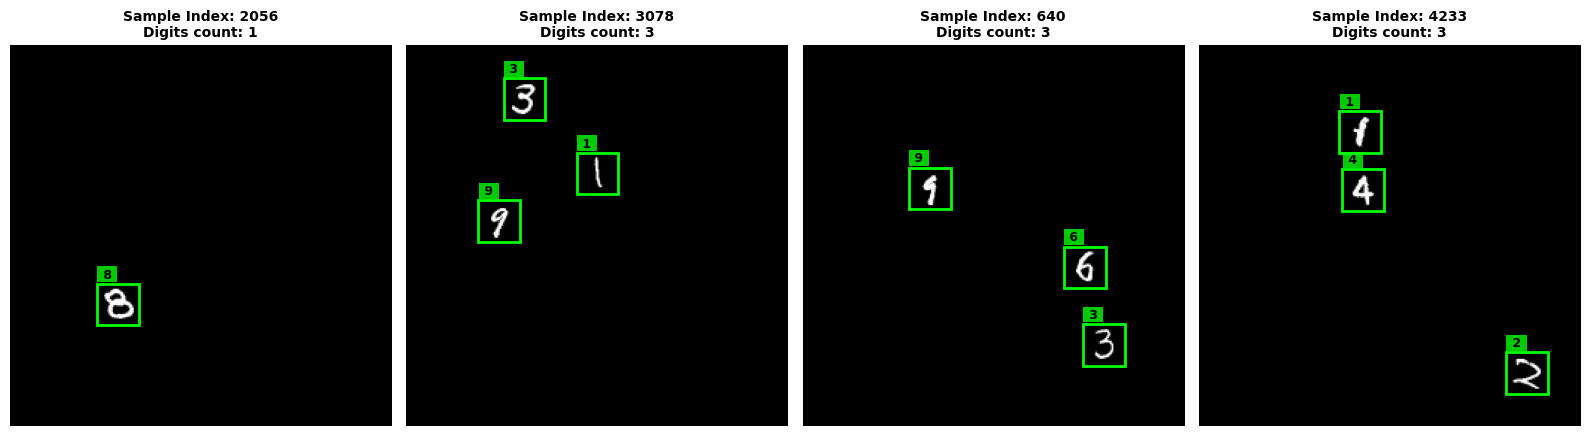

In [13]:
# Step 7: Visualize the Generated Synthetic Dataset
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_synthetic_samples(dataset, num_samples=4):
    fig, axes = plt.subplots(1, num_samples, figsize=(16, 5))
    if num_samples == 1:
        axes = [axes]
        
    for i in range(num_samples):
        # Pick a random sample
        idx = np.random.randint(0, len(dataset))
        img_tensor, gt_boxes, gt_classes = dataset[idx]
        
        # Un-normalize image (revert MNIST normalization)
        img = img_tensor.squeeze().numpy() * 0.3081 + 0.1307
        img = np.clip(img, 0.0, 1.0)
        
        ax = axes[i]
        ax.imshow(img, cmap='gray')
        ax.set_title(f"Sample Index: {idx}\nDigits count: {len(gt_boxes)}", fontsize=10, fontweight='bold')
        ax.axis('off')
        
        # Draw bounding boxes and digit class labels
        for box, cls in zip(gt_boxes, gt_classes):
            x1, y1, x2, y2 = box.numpy()
            w = x2 - x1
            h = y2 - y1
            
            # Green rectangle for ground truth box
            rect = patches.Rectangle((x1, y1), w, h, linewidth=2, edgecolor='#00FF00', facecolor='none')
            ax.add_patch(rect)
            
            # Label background & text
            ax.text(x1 + 1, y1 - 4, f" {cls.item()} ", color='black', fontsize=9, weight='bold',
                    bbox=dict(facecolor='#00FF00', alpha=0.8, pad=1, edgecolor='none'))

# Run visualization on the training dataset
visualize_synthetic_samples(train_dataset, num_samples=4)
plt.tight_layout()
plt.show()

In [14]:
# Step 8: Initialize Model, Optimizer, and Start Training
model = FasterRCNN(num_classes=11).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_faster_rcnn(model, train_loader, test_loader, optimizer, epochs=EPOCHS)

Starting training loop...
Epoch 1/10 | Batch 50/313 | Loss: 5.3326 | Acc: 76.48% | F1: 0.1808
Epoch 1/10 | Batch 100/313 | Loss: 2.9560 | Acc: 77.89% | F1: 0.1989
Epoch 1/10 | Batch 150/313 | Loss: 2.1533 | Acc: 78.66% | F1: 0.217
Epoch 1/10 | Batch 200/313 | Loss: 1.7461 | Acc: 79.23% | F1: 0.2315
Epoch 1/10 | Batch 250/313 | Loss: 1.4953 | Acc: 79.8% | F1: 0.2478
Epoch 1/10 | Batch 300/313 | Loss: 1.3248 | Acc: 80.28% | F1: 0.2658
Epoch 1/10 | Batch 313/313 | Loss: 1.2888 | Acc: 80.39% | F1: 0.2718
--- Epoch 1 Complete: Loss: 1.2888, Accuracy: 80.39%, F1: 0.2718 ---

Epoch 2/10 | Batch 50/313 | Loss: 0.4312 | Acc: 84.17% | F1: 0.4048
Epoch 2/10 | Batch 100/313 | Loss: 0.4149 | Acc: 84.73% | F1: 0.4281
Epoch 2/10 | Batch 150/313 | Loss: 0.4033 | Acc: 85.03% | F1: 0.4423
Epoch 2/10 | Batch 200/313 | Loss: 0.3892 | Acc: 85.5% | F1: 0.4625
Epoch 2/10 | Batch 250/313 | Loss: 0.3761 | Acc: 86.0% | F1: 0.4815
Epoch 2/10 | Batch 300/313 | Loss: 0.3635 | Acc: 86.54% | F1: 0.5007
Epoch 2/10 | 